# 30 — DT veins, central hotspot, and the ignition clock

The preheat/compression compromise is probably the dominant scale lever in the Roman target. This workbook makes the timing problem explicit without pretending to solve multidimensional hydrodynamics.

There are two physically different ignition jobs:

1. **Driver ignition:** DT veins must distribute ignition through the outer $p+{}^{15}$N layer early enough for Trajan pressure to create the implosion.
2. **Central-fuel ignition:** a compact central DT sphere may remain cold through most of the implosion and be heated near stagnation, after the high compression has already been assembled.

A late central kernel cannot be the cause of the earlier driver pressure unless a separate DT path carries ignition outward in time. The two clocks may share DT inventory or physical connections, but they cannot be merged causally.

In [1]:
from dataclasses import asdict
from math import inf

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from cno_sweep import load_builtin_rate
from cno_sweep.constants import SPEED_OF_LIGHT
from cno_sweep.ignition_timing import (
    front_timing_on_implosion_trace,
    screen_central_dt_hotspot,
)
from cno_sweep.layered_driver import evolve_layered_pressure_pulse
from cno_sweep.n15_pusher import (
    additive_volume_density,
    burn_time_for_fraction,
    mixture_state,
)
from cno_sweep.plasma import ideal_fully_ionized_sound_speed

pd.set_option("display.precision", 6)

## Model boundary

The compression history comes from workbook 35's concentric pressure model. A tagged inclusion is compressed either with the background or to equal cold-electron pressure. A burn front is represented only by its material-relative speed. If $\xi$ is the burned radius in material coordinates and $R_c(t)$ is the moving core radius,

$$\frac{d\xi}{dt}=\frac{v_{front}}{R_c(t)}.$$

This correctly credits the shrinking distance during implosion while avoiding a spatial hydro grid. It does not calculate shocks, conduction, instability, or the front speed itself.

Modern ICF work treats hotspot formation and subsequent alpha-driven propagation as separate, tightly coupled problems. A recent federal research-needs report explicitly identifies burn-wave propagation as a required measurement and modeling capability ([FESAC/LLNL report](https://lift.llnl.gov/sites/lift/files/2026-03/final_brn_report_011526.pdf)). A fast-ignition design study uses roughly 10-keV DT, a hotspot column around 0.5 g/cm², and sub-20-ps heating as an illustrative ignition scale—not as a universal criterion ([LANL fast-ignition white paper](https://lasers.llnl.gov/sites/lasers/files/2023-11/albright-LANL-IFE-workshop-2022.pdf)).

## Recreate the normalized cold implosion trajectory

This remains the deliberately favorable all-Trajan-to-one-recipe mechanical point. It gives us a trajectory on which to ask timing questions; it is not a globally allocated reference target.

In [2]:
carbon_density_kg_m3 = 2267.0
helium_density_kg_m3 = 125.0
core_density_kg_m3 = 17.0 / (13.0 / carbon_density_kg_m3 + 4.0 / helium_density_kg_m3)
driver_density_kg_m3 = additive_volume_density(4.0)

implosion = evolve_layered_pressure_pulse(
    event_id="timing-normalization",
    initial_core_radius_m=1.0,
    initial_core_density_kg_m3=core_density_kg_m3,
    initial_abundances={"c13": 1.0, "he4": 1.0},
    driver_n15_loaded_per_core_unit=1.0,
    driver_proton_ratio=4.0,
    n15_burn_fraction=1.0,
    dt_pairs_loaded_per_core_unit=0.0,
    dt_burn_fraction=0.0,
    dt_neutron_deposition_fraction=0.0,
    driver_density_kg_m3=driver_density_kg_m3,
    tamper_to_driver_mass_ratio=4.0,
    tamper_density_kg_m3=11340.0,
    burn_duration_over_characteristic_time=0.1,
)
display(pd.DataFrame([
    {"quantity": "mechanical time per metre of R0", "value": implosion.characteristic_time_s, "units": "s/m"},
    {"quantity": "peak time per metre of R0", "value": implosion.peak_time_s, "units": "s/m"},
    {"quantity": "peak compression", "value": implosion.peak_compression_ratio, "units": "ratio"},
    {"quantity": "Rf/R0", "value": implosion.peak_core_radius_m, "units": "ratio"},
    {"quantity": "driver thickness/R0", "value": implosion.initial_driver_thickness_m, "units": "ratio"},
]))

,quantity,value,units
0,mechanical time per metre of R0,1.433785e-07,s/m
1,peak time per metre of R0,4.429568e-07,s/m
2,peak compression,2.911136e+06,ratio
3,Rf/R0,7.003458e-03,ratio
4,driver thickness/R0,4.405175e-01,ratio


## Clock 1: local N15 induction sets an absolute minimum scale

DT veins can remove the need for a single slow N15 flame to traverse the entire mantle. They cannot remove the local time needed for hot N15 next to each vein to react. For constant-volume $p:{}^{15}$N fuel with $r=n_p/n_{15}=4$, exact two-reactant depletion gives the times below at ordinary driver density. The listed temperature is the fixed local temperature assumed to have been created by DT-vein charged products and other handoff processes. The calculation does not yet prove that the veins can supply or maintain it.

This is **not a shell-crossing calculation**. It asks how large the initial central-fuel radius $R_0$ must be if every N15 parcel is already locally ignited and its local burn may consume no more than 0.3 mechanical times. The corresponding driver thickness and complete target radius follow from the fixed mass-and-density geometry: $\Delta R_{driver}=0.4405R_0$ and $R_{out,0}=1.4685R_0$.

At $p:{}^{15}$N = 4, one initial N15 parcel has 5 ions and 11 electrons, so the classical heat needed to establish the state is $24kT$ per N15. The table compares that heat with $f_{15}Q$. A negative zero-loss margin means the requested partial burn cannot even repay its initial heating without additional DT energy, before expansion or radiation losses.

,N15 temperature (keV),N15 burn fraction,local burn time (us),minimum central R0 (m),implied N15-driver thickness (m),implied complete target radius (m),initial heat 24kT (MeV/N15),fusion released (MeV/initial N15),zero-loss fusion minus initial heat (MeV/N15)
0,80.0,0.1,0.755182,17.556840,7.734095,25.782229,1.92,0.4966,-1.4234
1,80.0,0.3,2.629589,61.133948,26.930573,89.775235,1.92,1.4898,-0.4302
2,80.0,0.5,5.279830,122.748034,54.072655,180.255553,1.92,2.4830,0.5630
3,100.0,0.1,0.395626,9.197695,4.051745,13.506820,2.40,0.4966,-1.9034
4,100.0,0.3,1.377591,32.026914,14.108415,47.031539,2.40,1.4898,-0.9102
5,100.0,0.5,2.766002,64.305363,28.327636,94.432459,2.40,2.4830,0.0830
6,150.0,0.1,0.149519,3.476096,1.531281,5.104648,3.60,0.4966,-3.1034
7,150.0,0.3,0.520635,12.103969,5.332010,17.774684,3.60,1.4898,-2.1102
8,150.0,0.5,1.045359,24.303000,10.705896,35.688969,3.60,2.4830,-1.1170
9,200.0,0.1,0.087841,2.042179,0.899616,2.998941,4.80,0.4966,-4.3034


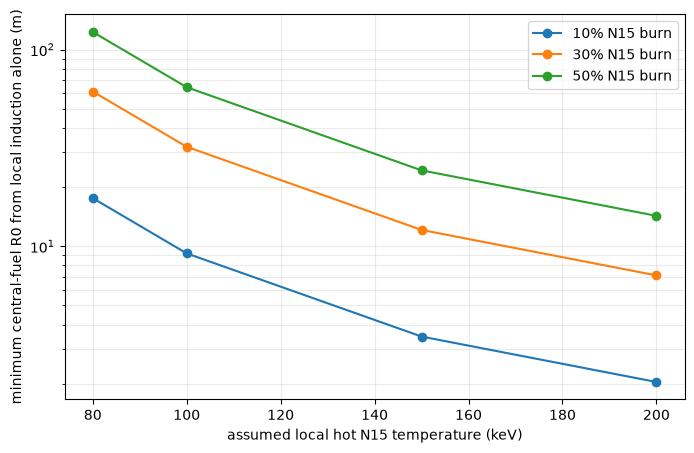

In [3]:
allowed_pulse_fraction = 0.30
induction_rows = []
for temperature_keV in [80.0, 100.0, 150.0, 200.0]:
    mixture = mixture_state(4.0, temperature_keV)
    rate = load_builtin_rate("n15-p-a-c12").rate_m3_s(temperature_keV)
    for burn_fraction in [0.10, 0.30, 0.50]:
        burn_time = burn_time_for_fraction(
            mixture.nitrogen_density_m3, 4.0, rate, burn_fraction
        )
        minimum_radius = burn_time / (allowed_pulse_fraction * implosion.characteristic_time_s)
        thermal_mev_per_n15 = 1.5 * mixture.thermal_particles_per_n15 * temperature_keV / 1000.0
        fusion_mev_per_n15 = burn_fraction * 4.966
        induction_rows.append({
            "N15 temperature (keV)": temperature_keV,
            "N15 burn fraction": burn_fraction,
            "local burn time (us)": burn_time * 1e6,
            "minimum central R0 (m)": minimum_radius,
            "implied N15-driver thickness (m)": minimum_radius * implosion.initial_driver_thickness_m,
            "implied complete target radius (m)": minimum_radius * implosion.initial_physical_outer_radius_m,
            "initial heat 24kT (MeV/N15)": thermal_mev_per_n15,
            "fusion released (MeV/initial N15)": fusion_mev_per_n15,
            "zero-loss fusion minus initial heat (MeV/N15)": fusion_mev_per_n15 - thermal_mev_per_n15,
        })
induction_table = pd.DataFrame(induction_rows)
display(induction_table)

fig, ax = plt.subplots(figsize=(8, 5))
for fraction, group in induction_table.groupby("N15 burn fraction"):
    ax.semilogy(group["N15 temperature (keV)"], group["minimum central R0 (m)"], "o-", label=f"{fraction:.0%} N15 burn")
ax.set(xlabel="assumed local hot N15 temperature (keV)", ylabel="minimum central-fuel R0 from local induction alone (m)")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
plt.show()

## Clock 2: DT-network traversal and vein spacing

Represent the heterogeneous vein network by one measurable quantity: the greatest material-path distance from an ignited DT segment to any N15 parcel. Write that distance as $L_{max}=\ell R_0$. Then

$$t_{network}=\frac{\ell R_0}{v_{DT}},$$

and a necessary timing condition is

$$t_{network}+t_{transfer}+t_{N15}\leq0.3t_*.$$

A single traversal of the complete 0.441-$R_0$ driver shell and a distributed mesh whose maximum path is 5% of that thickness are shown separately. The trial DT speeds are hypotheses to be replaced by a burn-front calculation or defensible bounds.

In [4]:
shell_path_fraction = implosion.initial_driver_thickness_m / implosion.initial_core_radius_m
mesh_path_fraction = 0.05 * shell_path_fraction
time_budget_per_metre = allowed_pulse_fraction * implosion.characteristic_time_s
critical_single_front_speed = shell_path_fraction / time_budget_per_metre
display(pd.DataFrame([
    {"topology": "one front crosses driver shell", "Lmax/R0": shell_path_fraction, "minimum speed even with zero N15 induction (m/s)": critical_single_front_speed},
    {"topology": "distributed veins, Lmax=5% shell thickness", "Lmax/R0": mesh_path_fraction, "minimum speed even with zero N15 induction (m/s)": mesh_path_fraction / time_budget_per_metre},
]))

network_rows = []
for temperature_keV in [100.0, 150.0, 200.0]:
    mixture = mixture_state(4.0, temperature_keV)
    rate = load_builtin_rate("n15-p-a-c12").rate_m3_s(temperature_keV)
    n15_time = burn_time_for_fraction(mixture.nitrogen_density_m3, 4.0, rate, 0.50)
    for dt_speed in [1e6, 3e6, 1e7]:
        remaining_time_per_metre = time_budget_per_metre - mesh_path_fraction / dt_speed
        minimum_radius = inf if remaining_time_per_metre <= 0 else n15_time / remaining_time_per_metre
        network_rows.append({
            "N15 T (keV)": temperature_keV,
            "assumed DT-network speed (m/s)": dt_speed,
            "maximum path/R0": mesh_path_fraction,
            "minimum R0 for network + 50% N15 burn (m)": minimum_radius,
        })
network_table = pd.DataFrame(network_rows)
display(network_table)

,topology,Lmax/R0,minimum speed even with zero N15 induction (m/s)
0,one front crosses driver shell,0.440517,1.024136e+07
1,"distributed veins, Lmax=5% shell thickness",0.022026,5.120682e+05


,N15 T (keV),assumed DT-network speed (m/s),maximum path/R0,minimum R0 for network + 50% N15 burn (m)
0,100.0,1000000.0,0.022026,131.791696
1,100.0,3000000.0,0.022026,77.540745
2,100.0,10000000.0,0.022026,67.775954
3,150.0,1000000.0,0.022026,49.808189
4,150.0,3000000.0,0.022026,29.305064
5,150.0,10000000.0,0.022026,25.614645
6,200.0,1000000.0,0.022026,29.261923
7,200.0,3000000.0,0.022026,17.216497
8,200.0,10000000.0,0.022026,15.048404


## Clock 3: compression of a central DT sphere

A central inclusion need not share exactly the same density ratio as C13+helium. The screen solves for the DT compression having the same zero-temperature electron overpressure as the surrounding core. This neglects interface inertia and shock entropy, but it is more physical than simply assigning the core compression to DT.

The kernel is then impulsively heated to 10 keV. Exact equimolar DT depletion is compared with its own sound-crossing time. The large $\rho R$ values mean charged products should be confined inside the complete target, but where DT-neutron energy is deposited still requires transport.

In [5]:
hotspot_rows = []
compression_points = [1e3, 1e4, 1e5, 5e5, 1e6, 2e6, implosion.peak_compression_ratio]
for initial_dt_radius_m in [0.08, 0.25]:
    for compression in compression_points:
        hotspot = screen_central_dt_hotspot(
            core_initial_density_kg_m3=core_density_kg_m3,
            core_mass_amu_per_unit=17.0,
            core_electrons_per_unit=8.0,
            core_compression_ratio=compression,
            initial_dt_radius_m=initial_dt_radius_m,
            initial_dt_density_kg_m3=250.0,
            temperature_keV=10.0,
            target_burn_fraction=0.50,
        )
        hotspot_rows.append({
            "initial DT radius (m)": initial_dt_radius_m,
            "core compression": compression,
            "DT compression": hotspot.dt_compression_ratio,
            "compressed DT radius (m)": hotspot.compressed_dt_radius_m,
            "DT rhoR (kg/m2)": hotspot.dt_rho_r_kg_m2,
            "DT 50% burn time (s)": hotspot.burn_time_s,
            "local sound time (s)": hotspot.local_sound_crossing_time_s,
            "burn time / local sound time": hotspot.burn_time_over_sound_crossing,
            "external heat to 10 keV (J)": hotspot.thermal_energy_j,
        })
hotspot_table = pd.DataFrame(hotspot_rows)
display(hotspot_table)

,initial DT radius (m),core compression,DT compression,compressed DT radius (m),DT rhoR (kg/m2),DT 50% burn time (s),local sound time (s),burn time / local sound time,external heat to 10 keV (J)
0,0.08,1.000000e+03,2.120069e+03,0.006227,3.300629e+03,1.432439e-10,5.490433e-09,0.026090,6.207849e+11
1,0.08,1.000000e+04,2.120078e+04,0.002890,1.532021e+04,1.432432e-11,2.548430e-09,0.005621,6.207849e+11
2,0.08,1.000000e+05,2.120079e+05,0.001342,7.111010e+04,1.432432e-12,1.182876e-09,0.001211,6.207849e+11
3,0.08,5.000000e+05,1.060039e+06,0.000785,2.079272e+05,2.864865e-13,6.917502e-10,0.000414,6.207849e+11
4,0.08,1.000000e+06,2.120079e+06,0.000623,3.300639e+05,1.432432e-13,5.490425e-10,0.000261,6.207849e+11
5,0.08,2.000000e+06,4.240157e+06,0.000494,5.239437e+05,7.162162e-14,4.357753e-10,0.000164,6.207849e+11
6,0.08,2.911136e+06,6.171836e+06,0.000436,6.729347e+05,4.920528e-14,3.845196e-10,0.000128,6.207849e+11
7,0.25,1.000000e+03,2.120069e+03,0.019461,1.031447e+04,1.432439e-10,1.715760e-08,0.008349,1.894485e+13
8,0.25,1.000000e+04,2.120078e+04,0.009033,4.787564e+04,1.432432e-11,7.963843e-09,0.001799,1.894485e+13
9,0.25,1.000000e+05,2.120079e+05,0.004193,2.222191e+05,1.432432e-12,3.696488e-09,0.000388,1.894485e+13


## Why the center and the edge are different even in a reduced model

A local central hot spot cannot oppose the outer implosion until a pressure signal crosses the remaining cold fuel. A hot spot at the fuel/driver boundary communicates with that boundary immediately and is the strongest preheat penalty. These provide useful lower and upper bounds without pretending an off-centre three-dimensional spot is spherical.

For a central spot, compare the time remaining before peak compression with

$$t_{communicate}\sim\frac{R_c-R_h}{c_s}.$$

If $t_{communicate}$ exceeds the remaining implosion time, the central energy can ignite locally without having time to erase the already assembled global compression. It may still launch the desired outward burn or shock after stagnation.

In [6]:
hot_fuel_temperature_keV = 100.0
fuel_sound_speed = ideal_fully_ionized_sound_speed(
    core_density_kg_m3 * implosion.peak_compression_ratio,
    {"c13": 13.0 / 17.0, "he4": 4.0 / 17.0},
    hot_fuel_temperature_keV,
    hot_fuel_temperature_keV,
)
location_rows = []
for core_r0 in [10.0, 100.0, 500.0]:
    for compression in [1e3, 1e4, 1e5, 5e5, 1e6, 2e6]:
        unit_timing = front_timing_on_implosion_trace(implosion.trace, compression, 0.01)
        core_radius = core_r0 * compression ** (-1.0 / 3.0)
        hotspot = screen_central_dt_hotspot(
            core_initial_density_kg_m3=core_density_kg_m3,
            core_mass_amu_per_unit=17.0,
            core_electrons_per_unit=8.0,
            core_compression_ratio=compression,
            initial_dt_radius_m=0.08,
            initial_dt_density_kg_m3=250.0,
            temperature_keV=10.0,
            target_burn_fraction=0.50,
        )
        communication_time = max(0.0, core_radius - hotspot.compressed_dt_radius_m) / fuel_sound_speed
        remaining = unit_timing.time_before_peak_s * core_r0
        location_rows.append({
            "core R0 (m)": core_r0,
            "ignition compression": compression,
            "time remaining to peak (s)": remaining,
            "central pressure-communication time (s)": communication_time,
            "communication / remaining": communication_time / remaining if remaining > 0 else inf,
            "edge-hotspot communication / remaining": 0.0,
        })
location_table = pd.DataFrame(location_rows)
display(location_table)

,core R0 (m),ignition compression,time remaining to peak (s),central pressure-communication time (s),communication / remaining,edge-hotspot communication / remaining
0,10.0,1000.0,3.560144e-07,3.231145e-07,0.907588,0.0
1,10.0,10000.0,1.647775e-07,1.499765e-07,0.910176,0.0
2,10.0,100000.0,7.408607e-08,6.961291e-08,0.939622,0.0
3,10.0,500000.0,3.848861e-08,4.070988e-08,1.057712,0.0
4,10.0,1000000.0,2.650018e-08,3.231145e-08,1.219292,0.0
5,10.0,2000000.0,1.388959e-08,2.564562e-08,1.846391,0.0
6,100.0,1000.0,3.560144e-06,3.249368e-06,0.912707,0.0
7,100.0,10000.0,1.647775e-06,1.508223e-06,0.915309,0.0
8,100.0,100000.0,7.408607e-07,7.000551e-07,0.944921,0.0
9,100.0,500000.0,3.848861e-07,4.093947e-07,1.063678,0.0


## Clock 4: how fast must the central-fuel ignition wave propagate?

The table calculates the constant material-relative front speed required to reach the outside of the fuel by peak compression, and by one optimistic post-peak sound-crossing time. During the pre-peak interval it integrates the shrinking physical radius exactly from the zero-D trajectory.

The post-peak extension holds the peak radius fixed; real expansion makes that column optimistic. The speed is therefore an acceptance requirement for a later burn-front model, not an assumed achieved speed.

In [7]:
front_rows = []
peak_radius_per_r0 = implosion.peak_core_radius_m
for core_r0 in [10.0, 100.0, 500.0]:
    peak_disassembly_time = peak_radius_per_r0 * core_r0 / fuel_sound_speed
    for compression in [1e3, 1e4, 1e5, 5e5, 1e6, 2e6, implosion.peak_compression_ratio]:
        hotspot = screen_central_dt_hotspot(
            core_initial_density_kg_m3=core_density_kg_m3,
            core_mass_amu_per_unit=17.0,
            core_electrons_per_unit=8.0,
            core_compression_ratio=compression,
            initial_dt_radius_m=0.08,
            initial_dt_density_kg_m3=250.0,
            temperature_keV=10.0,
            target_burn_fraction=0.50,
        )
        current_core_radius = core_r0 * compression ** (-1.0 / 3.0)
        hot_fraction = min(0.99, hotspot.compressed_dt_radius_m / current_core_radius)
        # Scale the one-metre trace in both radius and time. Its required speed is invariant.
        timing = front_timing_on_implosion_trace(
            implosion.trace,
            compression,
            hot_fraction,
            post_peak_time_s=peak_disassembly_time / core_r0,
        )
        front_rows.append({
            "core R0 (m)": core_r0,
            "ignition compression": compression,
            "hotspot radius / core radius at ignition": hot_fraction,
            "required speed before peak (m/s)": timing.required_speed_before_peak_m_s,
            "required speed by peak + one sound time (m/s)": timing.required_speed_by_deadline_m_s,
            "required speed / hot-fuel sound speed": timing.required_speed_by_deadline_m_s / fuel_sound_speed,
        })
front_table = pd.DataFrame(front_rows)
display(front_table)
print(f"100-keV C13+He sound-speed screen: {fuel_sound_speed:.3e} m/s")

,core R0 (m),ignition compression,hotspot radius / core radius at ignition,required speed before peak (m/s),required speed by peak + one sound time (m/s),required speed / hot-fuel sound speed
0,10.0,1.000000e+03,0.006227,8.229513e+05,6.483758e+05,0.210812
1,10.0,1.000000e+04,0.006227,1.064539e+06,7.895463e+05,0.256712
2,10.0,1.000000e+05,0.006227,1.521766e+06,1.015942e+06,0.330323
3,10.0,5.000000e+05,0.006227,2.266942e+06,1.301576e+06,0.423193
4,10.0,1.000000e+06,0.006227,2.997345e+06,1.513305e+06,0.492035
5,10.0,2.000000e+06,0.006227,5.246721e+06,1.931352e+06,0.627958
6,10.0,2.911136e+06,0.006227,inf,3.056452e+06,0.993773
7,100.0,1.000000e+03,0.000623,8.275926e+05,6.520325e+05,0.212001
8,100.0,1.000000e+04,0.000623,1.070543e+06,7.939991e+05,0.258160
9,100.0,1.000000e+05,0.000623,1.530348e+06,1.021672e+06,0.332186


100-keV C13+He sound-speed screen: 3.076e+06 m/s


## Interpretation and workbook handoff

The reduced model supports the central intuition, with qualifications:

- **A central DT spot can be ignited very late.** At the high cold-compression bound, its calculated DT reaction time is far below its local sound time. A small central spot also takes roughly a fuel sound-crossing time to communicate pressure to the outer core, so it need not impose the catastrophic uniform-preheat penalty before stagnation.
- **An edge spot is mechanically different.** Its pressure reaches the driver-facing boundary immediately. It is appropriately bracketed by the early/boundary-preheat limit, not by the protected central limit.
- **Late ignition transfers the difficulty to propagation.** Ignition exactly at peak requires a central-fuel wave approaching the hot-fuel sound speed if most fuel must burn within one disassembly time. Earlier ignition relaxes this but increases the risk of spoiling compression. This is the actual optimization.
- **The N15 driver has a different timing problem.** Its local 80–200-keV reaction time is an absolute clock. Making the target larger lengthens the mechanical time until that clock fits. DT veins reduce the network distance but do not eliminate N15 induction time.
- **A single central kernel does not automatically ignite the driver.** Without a DT trunk through the central fuel, it is separated from the N15 mantle. If it waits until peak compression, it is too late to have caused that compression. The reference architecture should therefore carry an early driver starter/network and a late central hotspot as separate line items, even if a later design physically connects them.
- **DT neutrons are not automatically uniform heating.** A central source guarantees geometrical interception by a sufficiently thick fuel ball, but high compression shortens the neutron mean free path. We must calculate whether energy is deposited centrally, throughout the fuel, or in parasitic reactions.

The next numerical refinement should replace three exposed quantities—DT-network speed, vein-to-N15 transfer time, and central-fuel front speed—with likely and conservative functions of local density and temperature. A two-zone hotspot/cold-shell pressure model should then replace the two limiting statements ‘central heat isolated’ and ‘heat instantly uniform.’